In [49]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [50]:
class QuadState(TypedDict):

    a : int
    b : int
    c : int 

    equation : str
    disc : float
    result : str
    

In [51]:
def show_equation(state: QuadState):

    equation = f'{state["a"]}x2{state["b"]}x{state["c"]}'

    return {'equation':equation}

def calculate_disc(state: QuadState):

    disc = state['b']**2 - 4*state['a']*state['c']

    return {'disc':disc}

In [52]:
def real_roots(state: QuadState):

    root1 = (-state["b"] + state["disc"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["disc"]**0.5)/(2*state["a"])

    result = f'The roots are {root1} and {root2}'

    return {'result': result}



In [53]:
def repeated_roots(state: QuadState):

    root = (-state["b"])/(2*state["a"])

    result = f'Only repeating root is {root}'

    return {'result': result}

In [54]:

def no_real_roots(state: QuadState):

    result = f'No real roots'

    return {'result': result}

In [55]:
def check_condition(state: QuadState) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:

    if state['disc'] > 0:
        return "real_roots"
    elif state['disc'] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"

In [56]:
graph = StateGraph(QuadState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_disc', calculate_disc)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

## edge 
graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_disc')
graph.add_conditional_edges('calculate_disc', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

workflow = graph.compile()

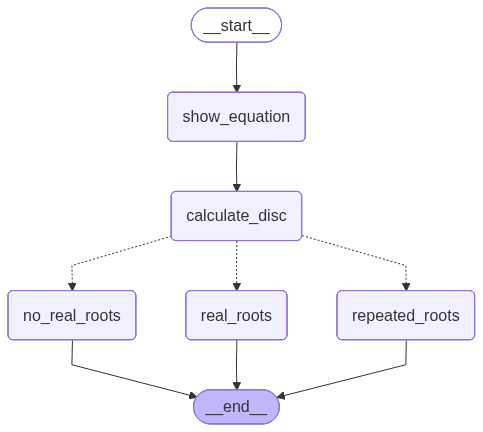

In [57]:
workflow

In [59]:
initial_state = {
    'a' : 3,
    'b' : -2,
    'c' : 8
}

workflow.invoke(initial_state)

{'a': 3,
 'b': -2,
 'c': 8,
 'equation': '3x2-2x8',
 'disc': -92,
 'result': 'No real roots'}